# Experimento 1 — Rendimiento de I/O: HDFS vs. Sistema Local
**Procesamiento de Alto Volúmen de Datos — PUJ**

## Objetivo
Medir y comparar el **throughput de lectura/escritura** al usar HDFS distribuido frente al sistema de ficheros local, para diferentes tamaños de archivos CSV sintéticos.

## Hipótesis
HDFS supera al almacenamiento local en lectura de archivos grandes gracias al paralelismo de sus DataNodes, pero tiene mayor latencia en archivos pequeños por la sobrecarga del NameNode.

## Métricas
- Tiempo de escritura (s)
- Tiempo de lectura (s)  
- Throughput (MB/s)
- Número de bloques HDFS generados

In [13]:
# ── Configuración ──────────────────────────────────────────────────────────
import os, time, subprocess, random, string
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pyspark.sql import SparkSession
from pyspark.sql.types import *

MASTER_IP    = '10.43.97.145'        # ← Cambia por tu IP
SPARK_MASTER = f'spark://{MASTER_IP}:7077'
HDFS_URI     = f'hdfs://{MASTER_IP}:9000'
CONDA_ENV    = '/opt/conda_envs/pyspark_env'
HADOOP_HOME  = '/nfs/condor/apps/hadoop-3.5.0'
HADOOP_BIN   = f'{HADOOP_HOME}/bin/hdfs'
LOCAL_DIR    = '/tmp/exp1_local'          # Directorio temporal en el driver
NFS_DIR      = '/nfs/condor/exp1_local'   # Directorio NFS visible en TODOS los nodos

os.makedirs(LOCAL_DIR, exist_ok=True)
os.makedirs(NFS_DIR, exist_ok=True)

# Forzar variables de entorno ANTES de crear la SparkSession
os.environ['PYSPARK_PYTHON']        = f'{CONDA_ENV}/bin/python'
os.environ['PYSPARK_DRIVER_PYTHON'] = f'{CONDA_ENV}/bin/python'

spark = (
    SparkSession.builder
    .appName('EXP1_IO_HDFS_vs_Local')
    .master(SPARK_MASTER)
    .config('spark.driver.host', MASTER_IP)           # Evita que los workers usen el hostname del laptop
    .config('spark.driver.bindAddress', MASTER_IP)    # Idem
    .config('spark.executor.memory', '2g')
    .config('spark.driver.memory', '2g')
    .config('spark.hadoop.fs.defaultFS', HDFS_URI)
    .getOrCreate()
)
print('SparkSession lista')
print(f'  Master  : {spark.sparkContext.master}')
print(f'  HDFS    : {HDFS_URI}')
print(f'  NFS dir : {NFS_DIR}')


SparkSession lista
  Master  : spark://10.43.97.145:7077
  HDFS    : hdfs://10.43.97.145:9000
  NFS dir : /nfs/condor/exp1_local


## 1.1 Generar datasets sintéticos de distintos tamaños

In [ ]:
def generar_csv(ruta_local: str, num_filas: int):
    """Genera un CSV con datos numéricos y de texto aleatorio."""
    rng = random.Random(42)
    with open(ruta_local, 'w') as f:
        f.write('id,nombre,edad,salario,departamento,score\n')
        departamentos = ['Ingenieria','Finanzas','Marketing','RRHH','IT','Legal']
        for i in range(num_filas):
            nombre  = ''.join(rng.choices(string.ascii_lowercase, k=8))
            edad    = rng.randint(22, 65)
            salario = round(rng.uniform(30000, 150000), 2)
            depto   = rng.choice(departamentos)
            score   = round(rng.uniform(0, 100), 4)
            f.write(f'{i},{nombre},{edad},{salario},{depto},{score}\n')
    tamanio_mb = os.path.getsize(ruta_local) / (1024**2)
    print(f'  {ruta_local}  →  {num_filas:,} filas  |  {tamanio_mb:.1f} MB')
    return tamanio_mb

# Tamaños: ~1 MB, ~50 MB, ~200 MB
datasets = [
    {'label': '1 MB',   'filas': 13_000},
    {'label': '30 MB',  'filas': 650_000},
    {'label': '100 MB', 'filas': 2_600_000},
    # {'label': '1 GB', 'filas': 20_000_000},
    {'label': '2 GB', 'filas': 50_000_000}   
]

print('Generando archivos locales y copiando a NFS...')
for ds in datasets:
    fname = f"datos_{ds['label'].replace(' ','')}.csv"
    local_path = f'{LOCAL_DIR}/{fname}'
    nfs_path   = f'{NFS_DIR}/{fname}'
    ds['local_path'] = local_path
    ds['nfs_path']   = nfs_path
    ds['size_mb']    = generar_csv(local_path, ds['filas'])
    # Copiar al NFS para que todos los workers lo vean
    import shutil
    shutil.copy(local_path, nfs_path)
    print(f'  → NFS: {nfs_path}')
print('\nDatasets listos.')


Generando archivos locales y copiando a NFS...
  /tmp/exp1_local/datos_1MB.csv  →  13,000 filas  |  0.5 MB
  → NFS: /nfs/condor/exp1_local/datos_1MB.csv
  /tmp/exp1_local/datos_30MB.csv  →  650,000 filas  |  26.8 MB
  → NFS: /nfs/condor/exp1_local/datos_30MB.csv
  /tmp/exp1_local/datos_100MB.csv  →  2,600,000 filas  |  109.1 MB
  → NFS: /nfs/condor/exp1_local/datos_100MB.csv


In [ ]:
datasets = [
    {'label': '1 MB',   'filas': 13_000},
    {'label': '30 MB',  'filas': 650_000},
    {'label': '100 MB', 'filas': 2_600_000},
    {'label': '1 GB', 'filas': 20_000_000},
    {'label': '2 GB', 'filas': 50_000_000}   
]

## 1.2 Medir escritura: local → HDFS (`hdfs dfs -put`)

In [10]:
def hdfs_put(local_path: str, hdfs_dir: str):
    """Copia un archivo local a HDFS y mide el tiempo."""
    t0 = time.perf_counter()
    subprocess.run([HADOOP_BIN, 'dfs', '-put', '-f', local_path, hdfs_dir], check=True)
    return time.perf_counter() - t0

print('Midiendo escritura a HDFS...\n')
for ds in datasets:
    hdfs_path = f"/experimentos/exp1_io/datos_{ds['label'].replace(' ','')}.csv"
    ds['hdfs_path']      = hdfs_path
    ds['tiempo_put']     = hdfs_put(ds['local_path'], '/experimentos/exp1_io/')
    ds['throughput_put'] = ds['size_mb'] / ds['tiempo_put']
    print(f"  {ds['label']:8s} → {ds['tiempo_put']:.2f}s  |  {ds['throughput_put']:.1f} MB/s")

Midiendo escritura a HDFS...



2026-05-21 20:16:06,981 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:07,013 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:07,700 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:07,725 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:07,948 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:07,966 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:08,028 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20

  1 MB     → 3.13s  |  0.2 MB/s


2026-05-21 20:16:09,663 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:09,691 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:10,181 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:10,201 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:10,371 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:10,390 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:10,447 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20

  50 MB    → 2.55s  |  10.5 MB/s


2026-05-21 20:16:12,267 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:12,292 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:12,779 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:12,799 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:12,989 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:13,009 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:13,065 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20

  200 MB   → 2.94s  |  37.1 MB/s


2026-05-21 20:16:15,164 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:15,189 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:15,675 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:15,692 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:15,860 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:15,877 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:16:15,938 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20

  2 GB     → 5.80s  |  147.5 MB/s


## 1.3 Verificar bloques replicados en HDFS

In [11]:
for ds in datasets:
    result = subprocess.run(
        [HADOOP_BIN, 'fsck', ds['hdfs_path'], '-files', '-blocks'],
        capture_output=True, text=True
    )
    # Extraer número de bloques de la salida
    for line in result.stdout.splitlines():
        if 'Total blocks' in line or 'blks' in line.lower():
            ds['bloques'] = line.strip()
            break
    else:
        ds['bloques'] = 'ver salida completa'
    print(f"  {ds['label']:8s} → {ds['bloques']}")
    print(result.stdout[-300:])   # Últimas líneas del fsck
    print('─' * 60)

  1 MB     → Total blocks (validated):	1 (avg. block size 540316 B)
 block groups:	0
 Average block group size:	0.0
 Missing block groups:		0
 Corrupt block groups:		0
 Missing internal blocks:	0
 Blocks queued for replication:	0
FSCK ended at Thu May 21 20:16:44 COT 2026 in 2 milliseconds


The filesystem under path '/experimentos/exp1_io/datos_1MB.csv' is HEALTHY

────────────────────────────────────────────────────────────
  50 MB    → Total blocks (validated):	1 (avg. block size 28126493 B)
block groups:	0
 Average block group size:	0.0
 Missing block groups:		0
 Corrupt block groups:		0
 Missing internal blocks:	0
 Blocks queued for replication:	0
FSCK ended at Thu May 21 20:16:47 COT 2026 in 1 milliseconds


The filesystem under path '/experimentos/exp1_io/datos_50MB.csv' is HEALTHY

────────────────────────────────────────────────────────────
  200 MB   → Total blocks (validated):	1 (avg. block size 114433579 B)
lock groups:	0
 Average block group size:	0.0
 Missing block groups

## 1.4 Medir lectura Spark desde HDFS vs. sistema local

In [14]:
def medir_lectura_spark(path: str) -> tuple:
    """Lee un CSV con Spark y devuelve (tiempo_s, num_filas).
    Acepta rutas hdfs://, file:// o rutas NFS (visibles en todos los nodos).
    """
    t0 = time.perf_counter()
    df = spark.read.csv(path, header=True, inferSchema=True)
    n  = df.count()        # acción que fuerza la lectura real
    t1 = time.perf_counter()
    return t1 - t0, n

print('Midiendo lectura HDFS vs. NFS (local compartido) con Spark...\n')
print('NOTA: La lectura "local" usa el NFS montado en todos los nodos,\n'
      '      que es el equivalente a "filesystem local" en este cluster.\n')

for ds in datasets:
    # Lectura desde HDFS (distribuida)
    hdfs_full = f"{HDFS_URI}{ds['hdfs_path']}"
    ds['tiempo_read_hdfs'], filas = medir_lectura_spark(hdfs_full)
    ds['throughput_read_hdfs'] = ds['size_mb'] / ds['tiempo_read_hdfs']

    # Lectura desde NFS (todos los workers pueden acceder)
    # file:// fuerza el scheme local, la ruta NFS es visible en cada nodo
    nfs_full = f"file://{ds['nfs_path']}"
    ds['tiempo_read_local'], _ = medir_lectura_spark(nfs_full)
    ds['throughput_read_local'] = ds['size_mb'] / ds['tiempo_read_local']

    print(f"  {ds['label']:8s} | HDFS: {ds['tiempo_read_hdfs']:.2f}s "
          f"({ds['throughput_read_hdfs']:.1f} MB/s) | "
          f"NFS:  {ds['tiempo_read_local']:.2f}s "
          f"({ds['throughput_read_local']:.1f} MB/s) | Filas: {filas:,}")


Midiendo lectura HDFS vs. NFS (local compartido) con Spark...

NOTA: La lectura "local" usa el NFS montado en todos los nodos,
      que es el equivalente a "filesystem local" en este cluster.



  1 MB     | HDFS: 7.94s (0.1 MB/s) | NFS:  2.16s (0.2 MB/s) | Filas: 13,000


  50 MB    | HDFS: 7.63s (3.5 MB/s) | NFS:  4.07s (6.6 MB/s) | Filas: 650,000


  200 MB   | HDFS: 3.49s (31.3 MB/s) | NFS:  1.76s (61.9 MB/s) | Filas: 2,600,000


  2 GB     | HDFS: 4.47s (191.7 MB/s) | NFS:  3.80s (225.2 MB/s) | Filas: 20,000,000


## 1.5 Tabla de resultados y visualización

In [16]:
# ── Tabla resumen ──────────────────────────────────────────────────────────
resultados = pd.DataFrame([{
    'Tamaño'           : ds['label'],
    'MB reales'        : round(ds['size_mb'], 1),
    'Put HDFS (s)'     : round(ds['tiempo_put'], 2),
    'TP Put (MB/s)'    : round(ds['throughput_put'], 1),
    'Read HDFS (s)'    : round(ds['tiempo_read_hdfs'], 2),
    'TP HDFS (MB/s)'   : round(ds['throughput_read_hdfs'], 1),
    'Read NFS (s)'     : round(ds['tiempo_read_local'], 2),
    'TP NFS (MB/s)'    : round(ds['throughput_read_local'], 1),
} for ds in datasets])

print('\nTABLA DE RESULTADOS — Experimento 1 (HDFS vs NFS)')
print(resultados.to_string(index=False))
resultados.to_csv('/tmp/exp1_resultados.csv', index=False)
print('\nGuardado en /tmp/exp1_resultados.csv')



TABLA DE RESULTADOS — Experimento 1 (HDFS vs NFS)
Tamaño  MB reales  Put HDFS (s)  TP Put (MB/s)  Read HDFS (s)  TP HDFS (MB/s)  Read NFS (s)  TP NFS (MB/s)
  1 MB        0.5          3.13            0.2           7.94             0.1          2.16            0.2
 50 MB       26.8          2.55           10.5           7.63             3.5          4.07            6.6
200 MB      109.1          2.94           37.1           3.49            31.3          1.76           61.9
  2 GB      856.1          5.80          147.5           4.47           191.7          3.80          225.2

Guardado en /tmp/exp1_resultados.csv


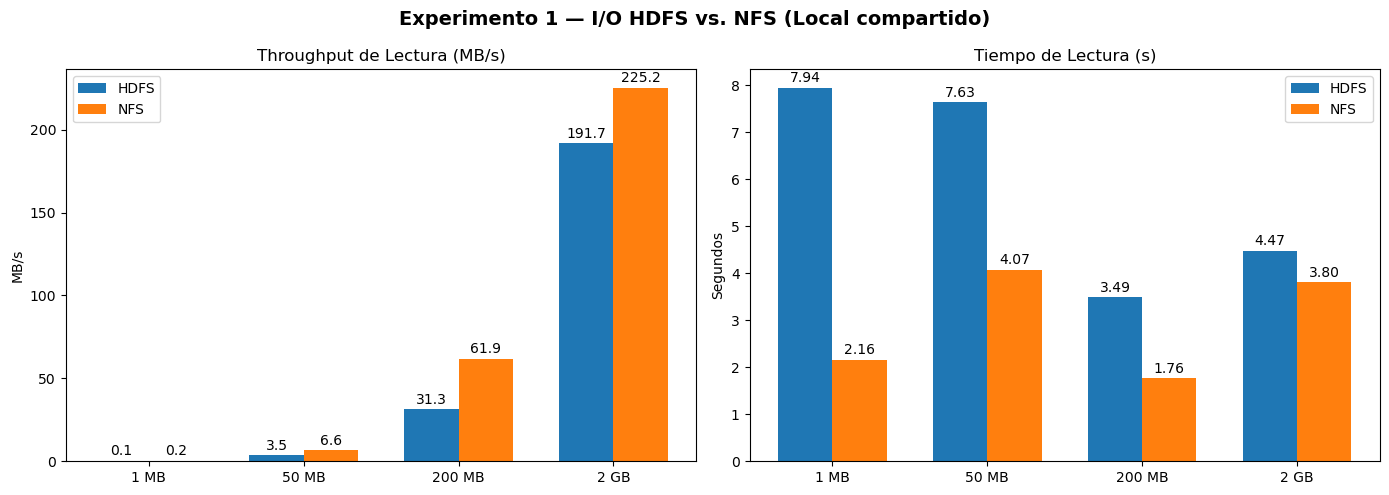

Gráfica guardada en /tmp/exp1_grafica.png


In [18]:
# ── Gráficas ───────────────────────────────────────────────────────────────
labels   = [ds['label'] for ds in datasets]
x        = range(len(labels))
width    = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experimento 1 — I/O HDFS vs. NFS (Local compartido)', fontsize=14, fontweight='bold')

# Throughput de lectura
ax = axes[0]
b1 = ax.bar([i - width/2 for i in x], [ds['throughput_read_hdfs']  for ds in datasets],
            width, label='HDFS', color='#1F77B4')
b2 = ax.bar([i + width/2 for i in x], [ds['throughput_read_local'] for ds in datasets],
            width, label='NFS', color='#FF7F0E')
ax.set_title('Throughput de Lectura (MB/s)')
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel('MB/s'); ax.legend()
ax.bar_label(b1, fmt='%.1f', padding=2)
ax.bar_label(b2, fmt='%.1f', padding=2)

# Tiempo de lectura
ax2 = axes[1]
b3 = ax2.bar([i - width/2 for i in x], [ds['tiempo_read_hdfs']  for ds in datasets],
             width, label='HDFS', color='#1F77B4')
b4 = ax2.bar([i + width/2 for i in x], [ds['tiempo_read_local'] for ds in datasets],
             width, label='NFS', color='#FF7F0E')
ax2.set_title('Tiempo de Lectura (s)')
ax2.set_xticks(list(x)); ax2.set_xticklabels(labels)
ax2.set_ylabel('Segundos'); ax2.legend()
ax2.bar_label(b3, fmt='%.2f', padding=2)
ax2.bar_label(b4, fmt='%.2f', padding=2)

plt.tight_layout()
plt.savefig('/tmp/exp1_grafica.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada en /tmp/exp1_grafica.png')


In [8]:
spark.stop()
print('SparkSession detenida.')

SparkSession detenida.
